In [1]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

image = plt.imread("./flower.png")
print(image.shape)

(64, 64, 3)


In [2]:
preprocess = transforms.ToTensor()
x = preprocess(image)
print(image.shape)

(64, 64, 3)


In [3]:
def reverse_to_img(x):
    x = x * 255
    x = x.clamp(0, 255)
    x = x.to(torch.uint8)
    to_pil = transforms.ToPILImage()
    return to_pil(x)

# 最大时间步
T = 1000
# 方差计划的起始值
beta_start = 0.0001
# 方差计划的结束值
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)
print(betas)

tensor([1.0000e-04, 1.1992e-04, 1.3984e-04, 1.5976e-04, 1.7968e-04, 1.9960e-04,
        2.1952e-04, 2.3944e-04, 2.5936e-04, 2.7928e-04, 2.9920e-04, 3.1912e-04,
        3.3904e-04, 3.5896e-04, 3.7888e-04, 3.9880e-04, 4.1872e-04, 4.3864e-04,
        4.5856e-04, 4.7848e-04, 4.9840e-04, 5.1832e-04, 5.3824e-04, 5.5816e-04,
        5.7808e-04, 5.9800e-04, 6.1792e-04, 6.3784e-04, 6.5776e-04, 6.7768e-04,
        6.9760e-04, 7.1752e-04, 7.3744e-04, 7.5736e-04, 7.7728e-04, 7.9720e-04,
        8.1712e-04, 8.3704e-04, 8.5696e-04, 8.7688e-04, 8.9680e-04, 9.1672e-04,
        9.3664e-04, 9.5656e-04, 9.7648e-04, 9.9640e-04, 1.0163e-03, 1.0362e-03,
        1.0562e-03, 1.0761e-03, 1.0960e-03, 1.1159e-03, 1.1358e-03, 1.1558e-03,
        1.1757e-03, 1.1956e-03, 1.2155e-03, 1.2354e-03, 1.2554e-03, 1.2753e-03,
        1.2952e-03, 1.3151e-03, 1.3350e-03, 1.3550e-03, 1.3749e-03, 1.3948e-03,
        1.4147e-03, 1.4346e-03, 1.4546e-03, 1.4745e-03, 1.4944e-03, 1.5143e-03,
        1.5342e-03, 1.5542e-03, 1.5741e-

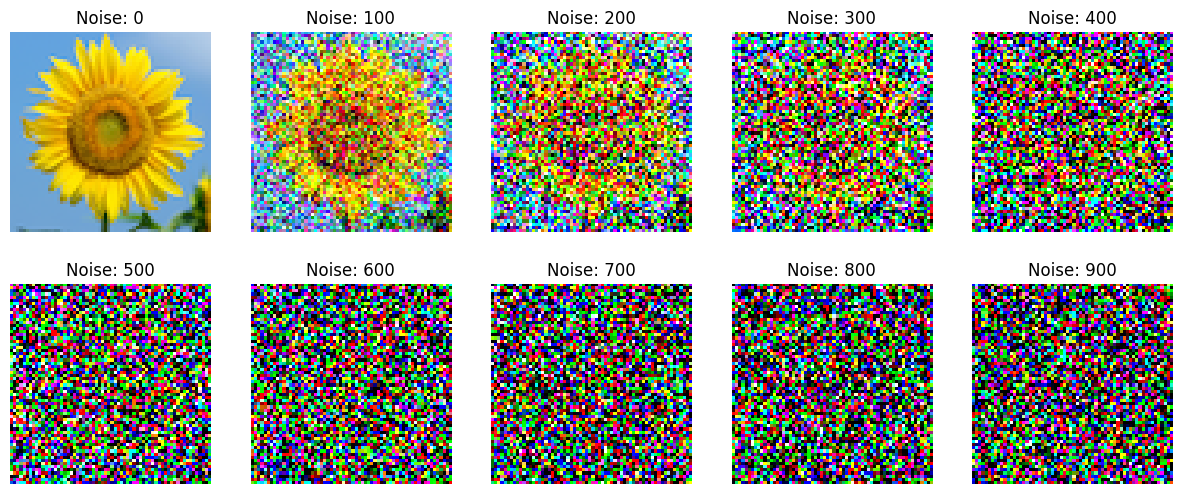

In [4]:
imgs = []

for t in range(T):
    if t % 100 == 0:
        img = reverse_to_img(x)
        imgs.append(img)
    
    beta = betas[t]
    eps = torch.randn_like(x) # 生成和x形状相同的噪声
    x = torch.sqrt(1 - beta) * x + torch.sqrt(beta) * eps

# 2行5列的方式显示10张图片
plt.figure(figsize=(15, 6))
for i, img in enumerate(imgs[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Noise: {i * 100}")
    plt.axis("off")

plt.show()